# 一人当たりに直して考えてみる

In [1]:
# csvファイル　country_population.csvを読み込む
import csv
with open(r"C:\修論研究\VWT_historical_data\country_population.csv", 'r', encoding='utf-8') as f:
    reader = csv.reader(f)
    for row in reader:
        print(row)
        

['Country Name', 'Country Code', 'Year', 'Value']
['Aruba', 'ABW', '1960', '54922']
['Aruba', 'ABW', '1961', '55578']
['Aruba', 'ABW', '1962', '56320']
['Aruba', 'ABW', '1963', '57002']
['Aruba', 'ABW', '1964', '57619']
['Aruba', 'ABW', '1965', '58190']
['Aruba', 'ABW', '1966', '58694']
['Aruba', 'ABW', '1967', '58990']
['Aruba', 'ABW', '1968', '59069']
['Aruba', 'ABW', '1969', '59052']
['Aruba', 'ABW', '1970', '58950']
['Aruba', 'ABW', '1971', '58781']
['Aruba', 'ABW', '1972', '58047']
['Aruba', 'ABW', '1973', '58299']
['Aruba', 'ABW', '1974', '58349']
['Aruba', 'ABW', '1975', '58295']
['Aruba', 'ABW', '1976', '58368']
['Aruba', 'ABW', '1977', '58580']
['Aruba', 'ABW', '1978', '58776']
['Aruba', 'ABW', '1979', '59191']
['Aruba', 'ABW', '1980', '59909']
['Aruba', 'ABW', '1981', '60563']
['Aruba', 'ABW', '1982', '61276']
['Aruba', 'ABW', '1983', '62228']
['Aruba', 'ABW', '1984', '62901']
['Aruba', 'ABW', '1985', '61728']
['Aruba', 'ABW', '1986', '59931']
['Aruba', 'ABW', '1987', '59159'

# netを人口で割ってみる

In [2]:
from __future__ import annotations

from typing import Optional, Tuple

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import TwoSlopeNorm


ISO3_FIX = {
    "FR": "FRA",
    "UK": "GBR",
    "EL": "GRC",
    "SP": "ESP",
    "SW": "SWE",
    "NO": "NOR",
    "JA": "JPN",
    "KO": "KOR",
    "CH": "CHN",
    "FR1": "FRA",
}

USSR_ALIASES = {"USSR", "SUN", "USS"}
USSR_NAME_ALIASES = {
    "USSR",
    "SOVIET UNION",
    "UNION OF SOVIET SOCIALIST REPUBLICS",
}


def _normalize_zip_shp_path(path: str) -> str:
    path = str(path)
    if path.startswith("zip://"):
        return path
    if ".zip!" in path.lower():
        return "zip://" + path
    return path


def _clean_iso3(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip().str.upper()
    return s.replace({"": np.nan, "NAN": np.nan, "NONE": np.nan, "-99": np.nan})


def _find_column(columns, *, exact=None, contains=None) -> Optional[str]:
    exact = exact or []
    contains = contains or []

    lowered = {str(c).strip().lower(): c for c in columns}
    for key in exact:
        if key.lower() in lowered:
            return lowered[key.lower()]

    for c in columns:
        low = str(c).strip().lower()
        if any(token.lower() in low for token in contains):
            return c
    return None


def _make_world_iso3_key(world: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    if "ISO_A3" not in world.columns:
        raise ValueError(f"world に ISO_A3 列が無い。columns={list(world.columns)}")

    world = world.copy()
    world["_iso3"] = _clean_iso3(world["ISO_A3"])
    invalid = world["_iso3"].isna()

    if "ADM0_A3" in world.columns:
        world.loc[invalid, "_iso3"] = _clean_iso3(world.loc[invalid, "ADM0_A3"])
        invalid = world["_iso3"].isna()

    if "SOV_A3" in world.columns:
        world.loc[invalid, "_iso3"] = _clean_iso3(world.loc[invalid, "SOV_A3"])
        invalid = world["_iso3"].isna()

    world["_iso3"] = world["_iso3"].replace(ISO3_FIX)
    world.loc[invalid, "_iso3"] = np.nan
    return world


def extract_population_by_iso3_for_year(
    population_df: pd.DataFrame,
    year: int,
    *,
    iso3_col: Optional[str] = None,
    year_col: Optional[str] = None,
    pop_col: Optional[str] = None,
    ussr_until_year: int = 1991,
) -> pd.DataFrame:
    if population_df is None or len(population_df) == 0:
        raise ValueError("population_df が空です。")

    pop = population_df.copy()
    y = int(year)

    if iso3_col is None:
        iso3_col = _find_column(
            pop.columns,
            exact=["iso3", "iso_a3", "iso-3", "iso_3", "country code", "country_code", "code"],
            contains=["iso3"],
        )
    if iso3_col is None:
        raise ValueError(
            f"人口データの ISO3 列を特定できません。iso3_col を指定してください。columns={list(pop.columns)}"
        )

    if year_col is not None or pop_col is not None:
        if year_col is None or pop_col is None:
            raise ValueError("year_col と pop_col はセットで指定してください。")
        long = pop[[iso3_col, year_col, pop_col]].copy()
        long["_year"] = pd.to_numeric(long[year_col], errors="coerce")
        long = long[long["_year"] == y]
        out = long[[iso3_col, pop_col]].rename(columns={iso3_col: "iso3", pop_col: "population"})
    else:
        year_col_wide = None
        for c in pop.columns:
            if str(c).strip() == str(y):
                year_col_wide = c
                break

        if year_col_wide is not None:
            out = pop[[iso3_col, year_col_wide]].rename(columns={iso3_col: "iso3", year_col_wide: "population"})
        else:
            auto_year_col = _find_column(pop.columns, exact=["year", "yr"], contains=["year"])
            auto_pop_col = _find_column(pop.columns, exact=["population", "pop", "value"], contains=["pop"])
            if auto_year_col is None or auto_pop_col is None:
                raise ValueError(
                    "人口データ形式を自動判定できません。"
                    " long形式なら year_col/pop_col、wide形式なら年列（例: '2015'）を確認してください。"
                )
            long = pop[[iso3_col, auto_year_col, auto_pop_col]].copy()
            long["_year"] = pd.to_numeric(long[auto_year_col], errors="coerce")
            long = long[long["_year"] == y]
            out = long[[iso3_col, auto_pop_col]].rename(columns={iso3_col: "iso3", auto_pop_col: "population"})

    out = out.copy()
    out["iso3"] = _clean_iso3(out["iso3"]).replace(ISO3_FIX)
    if y <= int(ussr_until_year):
        out["iso3"] = out["iso3"].replace({k: "RUS" for k in USSR_ALIASES})

    out["population"] = pd.to_numeric(out["population"], errors="coerce")
    out = out[out["iso3"].notna() & np.isfinite(out["population"]) & (out["population"] > 0)].copy()
    out = out.groupby("iso3", as_index=False)["population"].sum()
    return out


def plot_vwt_net_import_export_map_debug_percapita(
    year: int,
    crop: int,
    *,
    country_list_xlsx: str,
    vwt_npy_template: str,
    ne_countries_shp: str,
    population_df: pd.DataFrame,
    pop_iso3_col: Optional[str] = None,
    pop_year_col: Optional[str] = None,
    pop_value_col: Optional[str] = None,
    population_year: Optional[int] = None,
    xlim=(-180, 180),
    ylim=(-60, 85),
    top_n_print: int = 20,
    percapita_unit: str = "m^3/person/year",
    cmap: str = "seismic",
    clip_quantile: Optional[float] = 0.995,
    missing_color: str = "#BEBEBE",
    border_color: str = "#444444",
    border_lw: float = 0.35,
    show_missing_legend: bool = True,
    debug_iso3: str = "FRA",
    print_no_match_samples: int = 30,
    print_df_only_samples: int = 30,
    ussr_until_year: int = 1991,
) -> Tuple[pd.DataFrame, gpd.GeoDataFrame]:
    debug_iso3 = str(debug_iso3).strip().upper()
    y = int(year)
    pop_y = int(population_year) if population_year is not None else y
    pre_ussr = y <= int(ussr_until_year)

    if pre_ussr and debug_iso3 in USSR_ALIASES:
        debug_iso3 = "RUS"

    vwt_path = vwt_npy_template.format(crop=crop, year=year)
    vwt_mat = np.load(vwt_path).astype(float)
    if vwt_mat.ndim != 2:
        raise ValueError(f"VWTmat must be 2D. got shape={vwt_mat.shape}")

    nrow, ncol = vwt_mat.shape
    if nrow != ncol:
        print(f"[WARN] VWTmat is not square: {vwt_mat.shape}. row/colの向きを要確認")

    n = min(nrow, ncol)
    vwt_mat = vwt_mat[:n, :n]
    print("VWTmat shape:", vwt_mat.shape)
    print("VWT file:", vwt_path)

    cl = pd.read_excel(country_list_xlsx)
    iso3_col = _find_column(cl.columns, exact=["iso3", "iso_a3", "iso-3", "iso_3"], contains=["iso3"])
    if iso3_col is None:
        raise ValueError(f"country_list に ISO3 列が見つからない。columns={list(cl.columns)}")
    if len(cl) < n:
        raise ValueError(f"country_list rows ({len(cl)}) < VWT size ({n}). country_listの行数が足りない。")

    cl_n = cl.iloc[:n].copy()
    cl_n["_iso3_raw"] = cl_n[iso3_col].astype(str)
    cl_n["_iso3"] = _clean_iso3(cl_n["_iso3_raw"]).replace(ISO3_FIX)

    country_name_col = _find_column(cl_n.columns, exact=["country name", "country", "name"], contains=["country"])
    if country_name_col is None:
        country_name_col = cl_n.columns[0]

    cl_n["_country_upper"] = cl_n[country_name_col].astype(str).str.strip().str.upper()
    missing_iso = cl_n["_iso3"].isna()
    cl_n.loc[missing_iso & cl_n["_country_upper"].isin(USSR_NAME_ALIASES), "_iso3"] = "USSR"

    import_by_country = np.nansum(vwt_mat, axis=0)
    export_by_country = np.nansum(vwt_mat, axis=1)

    df_net = pd.DataFrame(
        {
            "iso3_raw": cl_n["_iso3"].values,
            "import": import_by_country,
            "export": export_by_country,
        }
    )
    if pre_ussr:
        df_net["iso3"] = df_net["iso3_raw"].replace({k: "RUS" for k in USSR_ALIASES})
    else:
        df_net["iso3"] = df_net["iso3_raw"]

    df_net = df_net[df_net["iso3"].notna()].copy()
    df_net = df_net.groupby("iso3", as_index=False)[["import", "export"]].sum()
    df_net["net"] = df_net["import"] - df_net["export"]

    pop_by_iso3 = extract_population_by_iso3_for_year(
        population_df=population_df,
        year=pop_y,
        iso3_col=pop_iso3_col,
        year_col=pop_year_col,
        pop_col=pop_value_col,
        ussr_until_year=ussr_until_year,
    )
    print(f"population year: {pop_y}, rows={len(pop_by_iso3)}")

    df_net = df_net.merge(pop_by_iso3, on="iso3", how="left")
    valid_pop = np.isfinite(df_net["population"]) & (df_net["population"] > 0)
    for col in ["import", "export", "net"]:
        df_net[f"{col}_pc"] = np.where(valid_pop, df_net[col] / df_net["population"], np.nan)

    print(f"population valid ratio: {int(valid_pop.sum())}/{len(df_net)}")

    df_pos = df_net[df_net["net_pc"] > 0].sort_values("net_pc", ascending=False)
    df_neg = df_net[df_net["net_pc"] < 0].sort_values("net_pc", ascending=True)
    print(f"\nTop {top_n_print} net per-capita positive (net_pc>0):")
    print(df_pos.head(top_n_print)[["iso3", "population", "import_pc", "export_pc", "net_pc"]])
    print(f"\nTop {top_n_print} net per-capita negative (net_pc<0):")
    print(df_neg.head(top_n_print)[["iso3", "population", "import_pc", "export_pc", "net_pc"]])

    ne_countries_shp = _normalize_zip_shp_path(ne_countries_shp)
    world = gpd.read_file(ne_countries_shp)
    world = _make_world_iso3_key(world)
    m = world.merge(df_net, left_on="_iso3", right_on="iso3", how="left")

    print("\n" + "=" * 70)
    print(f"[DEBUG] Investigate ISO3 = {debug_iso3}")
    print("=" * 70)
    print(f"[DEBUG] world has {debug_iso3}? ->", (world["_iso3"] == debug_iso3).any())
    print(f"[DEBUG] df_net has {debug_iso3}? ->", (df_net["iso3"] == debug_iso3).any())
    if (df_net["iso3"] == debug_iso3).any():
        print(df_net[df_net["iso3"] == debug_iso3][["iso3", "population", "import_pc", "export_pc", "net_pc"]].head(5))

    no_match = m[m["_iso3"].notna() & m["net_pc"].isna()][["_iso3"]].drop_duplicates()
    print(f"\n[DEBUG] sample world-iso3 but missing in df_net/pop (no match): n={len(no_match)}")
    print(no_match.head(print_no_match_samples).to_string(index=False))

    net_only = df_net[~df_net["iso3"].isin(world["_iso3"].dropna())][["iso3"]].drop_duplicates()
    print(f"\n[DEBUG] sample df_net iso3 but missing in world: n={len(net_only)}")
    print(net_only.head(print_df_only_samples).to_string(index=False))
    print("=" * 70 + "\n")

    vals = m["net_pc"].astype(float).to_numpy()
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        raise ValueError("net_pc の有効値が無い（人口マージ失敗 or population<=0）。")

    absvals = np.abs(vals)
    if clip_quantile is not None:
        q = float(clip_quantile)
        if not (0 < q <= 1):
            raise ValueError("clip_quantile must be in (0, 1].")
        vmax = float(np.nanquantile(absvals, q))
        if not np.isfinite(vmax) or vmax <= 0:
            vmax = float(np.nanmax(absvals))
    else:
        vmax = float(np.nanmax(absvals))

    if vmax == 0:
        vmax = 1.0

    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    fig, ax = plt.subplots(1, 1, figsize=(14, 7))
    ax.set_axis_off()
    ax.set_title(f"Virtual-water net per capita (import - export) [{percapita_unit}] | {year} (crop={crop})", fontsize=14)

    m.plot(ax=ax, color=missing_color, linewidth=0.0, edgecolor="none", zorder=1)
    has = np.isfinite(m["net_pc"].astype(float))
    m.loc[has].plot(
        ax=ax,
        column="net_pc",
        cmap=cmap,
        norm=norm,
        linewidth=0.0,
        edgecolor="none",
        legend=True,
        zorder=2,
    )
    m.boundary.plot(ax=ax, color=border_color, linewidth=border_lw, zorder=3)

    if show_missing_legend:
        from matplotlib.patches import Patch

        ax.legend(
            handles=[Patch(facecolor=missing_color, edgecolor="none", label="No data / no match / no population")],
            loc="lower left",
            frameon=True,
        )

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    plt.show()

    return df_net, m


VWTmat shape: (255, 255)
VWT file: C:\修論研究\VWT_historical_data\VWT_npy\VWT_56_2015.npy
population year: 2015, rows=265
population valid ratio: 210/231

Top 20 net per-capita positive (net_pc>0):
    iso3  population   import_pc  export_pc      net_pc
97   ISR   8380100.0  228.075742   2.874240  225.201502
48   CYP   1219502.0  205.877992   2.166671  203.711321
151  NLD  16939923.0  225.583028  57.956807  167.626222
93   IRL   4701957.0  175.857451  17.100656  158.756796
108  KOR  51014947.0  132.895004   0.000609  132.894395
144  NAM   2374300.0  123.402563   0.001156  123.401406
167  PRT  10358076.0  106.755133   1.689157  105.065976
45   CRI   4818038.0  101.163552   0.006979  101.156573
194  SWZ   1142813.0  100.717067   1.601610   99.115456
60   ESP  46422303.0  101.863540   2.920646   98.942894
142  MYS  31232798.0   97.337495   0.139021   97.198474
31   BWA   2203273.0   95.318165   0.031554   95.286612
55   DZA  40019529.0   86.412916   0.000000   86.412916
54   DOM  10434829.0 

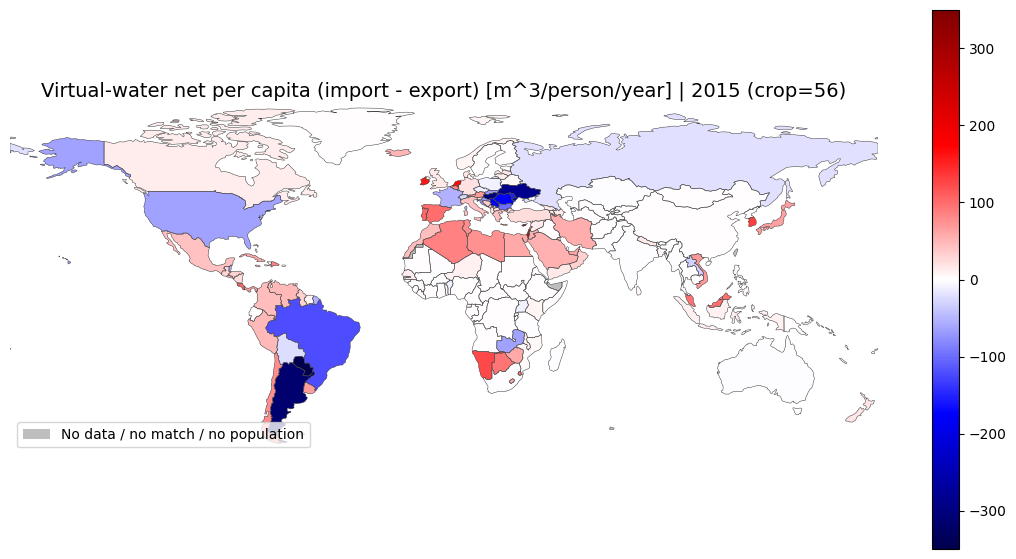

In [12]:
import csv
import pandas as pd
from percapita_utils import plot_vwt_net_import_export_map_debug_percapita

COUNTRY_POP_CSV   = r"C:\修論研究\VWT_historical_data\country_population.csv"
COUNTRY_LIST_XLSX = r"C:\修論研究\VWT_historical_data\country_list.xlsx"
VWT_NPY_TEMPLATE  = r"C:\修論研究\VWT_historical_data\VWT_npy\VWT_{crop}_{year}.npy"
NE_COUNTRIES_SHP  = r"C:\修論研究\ne_110m_admin_0_countries.zip!ne_110m_admin_0_countries.shp"

# country_population.csv を読み込み（Country Code, Year, Value）
rows = []
with open(COUNTRY_POP_CSV, "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        rows.append(row)

country_population = pd.DataFrame(rows)

df_net_pc, merged_map_pc = plot_vwt_net_import_export_map_debug_percapita(
    year=2015,
    crop=56,
    country_list_xlsx=COUNTRY_LIST_XLSX,
    vwt_npy_template=VWT_NPY_TEMPLATE,
    ne_countries_shp=NE_COUNTRIES_SHP,
    population_df=country_population,
    pop_iso3_col="Country Code",
    pop_year_col="Year",
    pop_value_col="Value",
    debug_iso3="RUS",
)


# アニメーション

In [4]:
from __future__ import annotations

from typing import Optional, Tuple

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.animation import FuncAnimation
from matplotlib.cm import ScalarMappable
from matplotlib.colors import TwoSlopeNorm


ISO3_FIX = {
    "FR": "FRA",
    "UK": "GBR",
    "EL": "GRC",
    "SP": "ESP",
    "SW": "SWE",
    "NO": "NOR",
    "JA": "JPN",
    "KO": "KOR",
    "CH": "CHN",
    "FR1": "FRA",
}

USSR_ALIASES = {"USSR", "SUN", "USS"}
USSR_NAME_ALIASES = {
    "USSR",
    "SOVIET UNION",
    "UNION OF SOVIET SOCIALIST REPUBLICS",
}
INVALID_ISO3 = {"-99", "NAN", "NONE", ""}


def _normalize_zip_shp_path(path: str) -> str:
    path = str(path)
    if path.startswith("zip://"):
        return path
    if ".zip!" in path.lower():
        return "zip://" + path
    return path


def _clean_iso3(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip().str.upper()
    return s.replace({"": np.nan, "NAN": np.nan, "NONE": np.nan, "-99": np.nan})


def _find_column(columns, *, exact=None, contains=None) -> Optional[str]:
    exact = exact or []
    contains = contains or []

    lowered = {str(c).strip().lower(): c for c in columns}
    for key in exact:
        if key.lower() in lowered:
            return lowered[key.lower()]

    for c in columns:
        low = str(c).strip().lower()
        if any(token.lower() in low for token in contains):
            return c
    return None


def _make_world_iso3_key(world: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    if "ISO_A3" not in world.columns:
        raise ValueError(f"world に ISO_A3 列が無い。columns={list(world.columns)}")

    world = world.copy()
    world["_iso3"] = _clean_iso3(world["ISO_A3"])
    invalid = world["_iso3"].isna()

    if "ADM0_A3" in world.columns:
        world.loc[invalid, "_iso3"] = _clean_iso3(world.loc[invalid, "ADM0_A3"])
        invalid = world["_iso3"].isna()

    if "SOV_A3" in world.columns:
        world.loc[invalid, "_iso3"] = _clean_iso3(world.loc[invalid, "SOV_A3"])
        invalid = world["_iso3"].isna()

    world["_iso3"] = world["_iso3"].replace(ISO3_FIX)
    world.loc[invalid, "_iso3"] = np.nan
    return world


def extract_population_by_iso3_for_year(
    population_df: pd.DataFrame,
    year: int,
    *,
    iso3_col: Optional[str] = None,
    year_col: Optional[str] = None,
    pop_col: Optional[str] = None,
    ussr_until_year: int = 1991,
) -> pd.DataFrame:
    if population_df is None or len(population_df) == 0:
        raise ValueError("population_df が空です。")

    pop = population_df.copy()
    y = int(year)

    if iso3_col is None:
        iso3_col = _find_column(
            pop.columns,
            exact=["iso3", "iso_a3", "iso-3", "iso_3", "country code", "country_code", "code"],
            contains=["iso3"],
        )
    if iso3_col is None:
        raise ValueError(
            f"人口データの ISO3 列を特定できません。iso3_col を指定してください。columns={list(pop.columns)}"
        )

    if year_col is not None or pop_col is not None:
        if year_col is None or pop_col is None:
            raise ValueError("year_col と pop_col はセットで指定してください。")
        long = pop[[iso3_col, year_col, pop_col]].copy()
        long["_year"] = pd.to_numeric(long[year_col], errors="coerce")
        long = long[long["_year"] == y]
        out = long[[iso3_col, pop_col]].rename(columns={iso3_col: "iso3", pop_col: "population"})
    else:
        year_col_wide = None
        for c in pop.columns:
            if str(c).strip() == str(y):
                year_col_wide = c
                break

        if year_col_wide is not None:
            out = pop[[iso3_col, year_col_wide]].rename(columns={iso3_col: "iso3", year_col_wide: "population"})
        else:
            auto_year_col = _find_column(pop.columns, exact=["year", "yr"], contains=["year"])
            auto_pop_col = _find_column(pop.columns, exact=["population", "pop", "value"], contains=["pop"])
            if auto_year_col is None or auto_pop_col is None:
                raise ValueError(
                    "人口データ形式を自動判定できません。"
                    " long形式なら year_col/pop_col、wide形式なら年列（例: '2015'）を確認してください。"
                )
            long = pop[[iso3_col, auto_year_col, auto_pop_col]].copy()
            long["_year"] = pd.to_numeric(long[auto_year_col], errors="coerce")
            long = long[long["_year"] == y]
            out = long[[iso3_col, auto_pop_col]].rename(columns={iso3_col: "iso3", auto_pop_col: "population"})

    out = out.copy()
    out["iso3"] = _clean_iso3(out["iso3"]).replace(ISO3_FIX)
    if y <= int(ussr_until_year):
        out["iso3"] = out["iso3"].replace({k: "RUS" for k in USSR_ALIASES})

    out["population"] = pd.to_numeric(out["population"], errors="coerce")
    out = out[out["iso3"].notna() & np.isfinite(out["population"]) & (out["population"] > 0)].copy()
    out = out.groupby("iso3", as_index=False)["population"].sum()
    return out


def plot_vwt_net_import_export_map_debug_percapita(
    year: int,
    crop: int,
    *,
    country_list_xlsx: str,
    vwt_npy_template: str,
    ne_countries_shp: str,
    population_df: pd.DataFrame,
    pop_iso3_col: Optional[str] = None,
    pop_year_col: Optional[str] = None,
    pop_value_col: Optional[str] = None,
    population_year: Optional[int] = None,
    xlim=(-180, 180),
    ylim=(-60, 85),
    top_n_print: int = 20,
    base_unit: str = "m^3/year",
    percapita_unit: str = "m^3/person/year",
    cmap: str = "seismic",
    clip_quantile: Optional[float] = 0.995,
    missing_color: str = "#BEBEBE",
    border_color: str = "#444444",
    border_lw: float = 0.35,
    show_missing_legend: bool = True,
    debug_iso3: str = "FRA",
    print_no_match_samples: int = 30,
    print_df_only_samples: int = 30,
    ussr_until_year: int = 1991,
) -> Tuple[pd.DataFrame, gpd.GeoDataFrame]:
    debug_iso3 = str(debug_iso3).strip().upper()
    y = int(year)
    pop_y = int(population_year) if population_year is not None else y
    pre_ussr = y <= int(ussr_until_year)

    if pre_ussr and debug_iso3 in USSR_ALIASES:
        debug_iso3 = "RUS"

    vwt_path = vwt_npy_template.format(crop=crop, year=year)
    vwt_mat = np.load(vwt_path).astype(float)
    if vwt_mat.ndim != 2:
        raise ValueError(f"VWTmat must be 2D. got shape={vwt_mat.shape}")

    nrow, ncol = vwt_mat.shape
    if nrow != ncol:
        print(f"[WARN] VWTmat is not square: {vwt_mat.shape}. row/colの向きを要確認")

    n = min(nrow, ncol)
    vwt_mat = vwt_mat[:n, :n]
    print("VWTmat shape:", vwt_mat.shape)
    print("VWT file:", vwt_path)

    cl = pd.read_excel(country_list_xlsx)
    iso3_col = _find_column(cl.columns, exact=["iso3", "iso_a3", "iso-3", "iso_3"], contains=["iso3"])
    if iso3_col is None:
        raise ValueError(f"country_list に ISO3 列が見つからない。columns={list(cl.columns)}")
    if len(cl) < n:
        raise ValueError(f"country_list rows ({len(cl)}) < VWT size ({n}). country_listの行数が足りない。")

    cl_n = cl.iloc[:n].copy()
    cl_n["_iso3_raw"] = cl_n[iso3_col].astype(str)
    cl_n["_iso3"] = _clean_iso3(cl_n["_iso3_raw"]).replace(ISO3_FIX)

    country_name_col = _find_column(cl_n.columns, exact=["country name", "country", "name"], contains=["country"])
    if country_name_col is None:
        country_name_col = cl_n.columns[0]

    cl_n["_country_upper"] = cl_n[country_name_col].astype(str).str.strip().str.upper()
    missing_iso = cl_n["_iso3"].isna()
    cl_n.loc[missing_iso & cl_n["_country_upper"].isin(USSR_NAME_ALIASES), "_iso3"] = "USSR"

    import_by_country = np.nansum(vwt_mat, axis=0)
    export_by_country = np.nansum(vwt_mat, axis=1)

    df_net = pd.DataFrame(
        {
            "iso3_raw": cl_n["_iso3"].values,
            "import": import_by_country,
            "export": export_by_country,
        }
    )
    if pre_ussr:
        df_net["iso3"] = df_net["iso3_raw"].replace({k: "RUS" for k in USSR_ALIASES})
    else:
        df_net["iso3"] = df_net["iso3_raw"]

    df_net = df_net[df_net["iso3"].notna()].copy()
    df_net = df_net.groupby("iso3", as_index=False)[["import", "export"]].sum()
    df_net["net"] = df_net["import"] - df_net["export"]

    pop_by_iso3 = extract_population_by_iso3_for_year(
        population_df=population_df,
        year=pop_y,
        iso3_col=pop_iso3_col,
        year_col=pop_year_col,
        pop_col=pop_value_col,
        ussr_until_year=ussr_until_year,
    )
    print(f"population year: {pop_y}, rows={len(pop_by_iso3)}")

    df_net = df_net.merge(pop_by_iso3, on="iso3", how="left")
    valid_pop = np.isfinite(df_net["population"]) & (df_net["population"] > 0)
    for col in ["import", "export", "net"]:
        df_net[f"{col}_pc"] = np.where(valid_pop, df_net[col] / df_net["population"], np.nan)

    print(f"population valid ratio: {int(valid_pop.sum())}/{len(df_net)}")

    df_pos = df_net[df_net["net_pc"] > 0].sort_values("net_pc", ascending=False)
    df_neg = df_net[df_net["net_pc"] < 0].sort_values("net_pc", ascending=True)
    print(f"\nTop {top_n_print} net per-capita positive (net_pc>0):")
    print(df_pos.head(top_n_print)[["iso3", "population", "import_pc", "export_pc", "net_pc"]])
    print(f"\nTop {top_n_print} net per-capita negative (net_pc<0):")
    print(df_neg.head(top_n_print)[["iso3", "population", "import_pc", "export_pc", "net_pc"]])

    ne_countries_shp = _normalize_zip_shp_path(ne_countries_shp)
    world = gpd.read_file(ne_countries_shp)
    world = _make_world_iso3_key(world)
    m = world.merge(df_net, left_on="_iso3", right_on="iso3", how="left")

    print("\n" + "=" * 70)
    print(f"[DEBUG] Investigate ISO3 = {debug_iso3}")
    print("=" * 70)
    print(f"[DEBUG] world has {debug_iso3}? ->", (world["_iso3"] == debug_iso3).any())
    print(f"[DEBUG] df_net has {debug_iso3}? ->", (df_net["iso3"] == debug_iso3).any())
    if (df_net["iso3"] == debug_iso3).any():
        print(df_net[df_net["iso3"] == debug_iso3][["iso3", "population", "import_pc", "export_pc", "net_pc"]].head(5))

    no_match = m[m["_iso3"].notna() & m["net_pc"].isna()][["_iso3"]].drop_duplicates()
    print(f"\n[DEBUG] sample world-iso3 but missing in df_net/pop (no match): n={len(no_match)}")
    print(no_match.head(print_no_match_samples).to_string(index=False))

    net_only = df_net[~df_net["iso3"].isin(world["_iso3"].dropna())][["iso3"]].drop_duplicates()
    print(f"\n[DEBUG] sample df_net iso3 but missing in world: n={len(net_only)}")
    print(net_only.head(print_df_only_samples).to_string(index=False))
    print("=" * 70 + "\n")

    vals = m["net_pc"].astype(float).to_numpy()
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        raise ValueError("net_pc の有効値が無い（人口マージ失敗 or population<=0）。")

    absvals = np.abs(vals)
    if clip_quantile is not None:
        q = float(clip_quantile)
        if not (0 < q <= 1):
            raise ValueError("clip_quantile must be in (0, 1].")
        vmax = float(np.nanquantile(absvals, q))
        if not np.isfinite(vmax) or vmax <= 0:
            vmax = float(np.nanmax(absvals))
    else:
        vmax = float(np.nanmax(absvals))

    if vmax == 0:
        vmax = 1.0

    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    fig, ax = plt.subplots(1, 1, figsize=(14, 7))
    ax.set_axis_off()
    ax.set_title(f"Virtual-water net per capita (import - export) [{percapita_unit}] | {year} (crop={crop})", fontsize=14)

    m.plot(ax=ax, color=missing_color, linewidth=0.0, edgecolor="none", zorder=1)
    has = np.isfinite(m["net_pc"].astype(float))
    m.loc[has].plot(
        ax=ax,
        column="net_pc",
        cmap=cmap,
        norm=norm,
        linewidth=0.0,
        edgecolor="none",
        legend=True,
        zorder=2,
    )
    m.boundary.plot(ax=ax, color=border_color, linewidth=border_lw, zorder=3)

    if show_missing_legend:
        from matplotlib.patches import Patch

        ax.legend(
            handles=[Patch(facecolor=missing_color, edgecolor="none", label="No data / no match / no population")],
            loc="lower left",
            frameon=True,
        )

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    plt.show()

    return df_net, m


def animate_vwt_net_import_export_percapita(
    crop: int,
    year_start: int,
    year_end: int,
    *,
    country_list_xlsx: str,
    vwt_npy_template: str,
    ne_countries_shp: str,
    population_df: pd.DataFrame,
    pop_iso3_col: Optional[str] = None,
    pop_year_col: Optional[str] = None,
    pop_value_col: Optional[str] = None,
    population_year: Optional[int] = None,
    xlim=(-180, 180),
    ylim=(-60, 85),
    percapita_unit: str = "m^3/person/year",
    fps: int = 6,
    interval_ms: Optional[int] = None,
    out_mp4: Optional[str] = None,
    out_gif: Optional[str] = None,
    dpi: int = 150,
    cmap: str = "seismic",
    clip_quantile: Optional[float] = 0.995,
    missing_color: str = "#BEBEBE",
    border_color: str = "#444444",
    border_lw: float = 0.35,
    show_missing_legend: bool = True,
    ussr_until_year: int = 1991,
) -> FuncAnimation:
    years = list(range(int(year_start), int(year_end) + 1))
    if len(years) == 0:
        raise ValueError("year_start <= year_end になるように指定してください。")
    if interval_ms is None:
        interval_ms = int(1000 / max(1, int(fps)))

    cl = pd.read_excel(country_list_xlsx)
    iso3_col = _find_column(cl.columns, exact=["iso3", "iso_a3", "iso-3", "iso_3"], contains=["iso3"])
    if iso3_col is None:
        raise ValueError(f"country_list に ISO3 列が見つからない。columns={list(cl.columns)}")

    vwt0 = np.load(vwt_npy_template.format(crop=crop, year=years[0])).astype(float)
    if vwt0.ndim != 2:
        raise ValueError(f"VWTmat must be 2D. got shape={vwt0.shape}")

    n = min(vwt0.shape[0], vwt0.shape[1])
    if vwt0.shape[0] != vwt0.shape[1]:
        print(f"[WARN] VWTmat is not square: {vwt0.shape}. row/colの向きを要確認")
    if len(cl) < n:
        raise ValueError(f"country_list rows ({len(cl)}) < VWT size ({n}). country_listの行数が足りない。")

    cl_n = cl.iloc[:n].copy()
    cl_n["_iso3_raw"] = cl_n[iso3_col].astype(str)
    cl_n["_iso3"] = _clean_iso3(cl_n["_iso3_raw"]).replace(ISO3_FIX)

    country_name_col = _find_column(cl_n.columns, exact=["country name", "country", "name"], contains=["country"])
    if country_name_col is None:
        country_name_col = cl_n.columns[0]
    cl_n["_country_upper"] = cl_n[country_name_col].astype(str).str.strip().str.upper()
    missing_iso = cl_n["_iso3"].isna()
    cl_n.loc[missing_iso & cl_n["_country_upper"].isin(USSR_NAME_ALIASES), "_iso3"] = "USSR"

    ne_countries_shp = _normalize_zip_shp_path(ne_countries_shp)
    world = gpd.read_file(ne_countries_shp)
    world = _make_world_iso3_key(world)

    pop_cache: dict[int, pd.DataFrame] = {}
    netpc_by_year: dict[int, pd.DataFrame] = {}
    global_abs_vals = []

    for y in years:
        vwt_y = np.load(vwt_npy_template.format(crop=crop, year=y)).astype(float)
        if vwt_y.ndim != 2:
            raise ValueError(f"年{y}のVWTmatが2次元でない: shape={vwt_y.shape}")
        if min(vwt_y.shape[0], vwt_y.shape[1]) < n:
            raise ValueError(f"年{y}のVWTサイズが小さい: {vwt_y.shape}, expected at least {n}x{n}")
        if vwt_y.shape[0] != vwt_y.shape[1]:
            print(f"[WARN] year={y}: VWTmat is not square: {vwt_y.shape}. row/colの向きを要確認")
        vwt_y = vwt_y[:n, :n]

        import_by_country = np.nansum(vwt_y, axis=0)
        export_by_country = np.nansum(vwt_y, axis=1)
        df_y = pd.DataFrame(
            {
                "iso3_raw": cl_n["_iso3"].values,
                "import": import_by_country,
                "export": export_by_country,
            }
        )
        if y <= int(ussr_until_year):
            df_y["iso3"] = df_y["iso3_raw"].replace({k: "RUS" for k in USSR_ALIASES})
        else:
            df_y["iso3"] = df_y["iso3_raw"]

        df_y = df_y[df_y["iso3"].notna()].copy()
        df_y = df_y.groupby("iso3", as_index=False)[["import", "export"]].sum()
        df_y["net"] = df_y["import"] - df_y["export"]

        pop_y = int(population_year) if population_year is not None else int(y)
        if pop_y not in pop_cache:
            pop_cache[pop_y] = extract_population_by_iso3_for_year(
                population_df=population_df,
                year=pop_y,
                iso3_col=pop_iso3_col,
                year_col=pop_year_col,
                pop_col=pop_value_col,
                ussr_until_year=ussr_until_year,
            )

        df_y = df_y.merge(pop_cache[pop_y], on="iso3", how="left")
        valid_pop = np.isfinite(df_y["population"]) & (df_y["population"] > 0)
        df_y["net_pc"] = np.where(valid_pop, df_y["net"] / df_y["population"], np.nan)
        netpc_by_year[y] = df_y[["iso3", "net_pc"]].copy()

        vals = df_y["net_pc"].to_numpy(dtype=float)
        vals = vals[np.isfinite(vals)]
        if vals.size > 0:
            global_abs_vals.append(np.abs(vals))

    if len(global_abs_vals) == 0:
        raise ValueError("全年で net_pc の有効値が無い（人口マージ失敗 or population<=0）。")
    global_abs_vals = np.concatenate(global_abs_vals)

    if clip_quantile is not None:
        q = float(clip_quantile)
        if not (0 < q <= 1):
            raise ValueError("clip_quantile must be in (0, 1].")
        vmax = float(np.nanquantile(global_abs_vals, q))
        if not np.isfinite(vmax) or vmax <= 0:
            vmax = float(np.nanmax(global_abs_vals))
    else:
        vmax = float(np.nanmax(global_abs_vals))

    if not np.isfinite(vmax) or vmax <= 0:
        vmax = 1.0

    print(f"Global per-capita scale: vmax={vmax:g} (clip_quantile={clip_quantile})")
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    fig, ax = plt.subplots(1, 1, figsize=(14, 7))
    ax.set_axis_off()
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label(f"net per capita (import - export) [{percapita_unit}]")

    def update(frame_i: int):
        y = years[frame_i]
        ax.cla()
        ax.set_axis_off()
        pop_label = int(population_year) if population_year is not None else y
        ax.set_title(
            f"Virtual-water net per capita (import - export) [{percapita_unit}] | {y} (pop={pop_label}, crop={crop})",
            fontsize=14,
        )

        m = world.merge(netpc_by_year[y], left_on="_iso3", right_on="iso3", how="left")
        m.plot(ax=ax, color=missing_color, linewidth=0.0, edgecolor="none", zorder=1)

        has = np.isfinite(m["net_pc"].astype(float))
        if has.any():
            m.loc[has].plot(
                ax=ax,
                column="net_pc",
                cmap=cmap,
                norm=norm,
                linewidth=0.0,
                edgecolor="none",
                legend=False,
                zorder=2,
            )

        m.boundary.plot(ax=ax, color=border_color, linewidth=border_lw, zorder=3)

        if show_missing_legend:
            from matplotlib.patches import Patch

            ax.legend(
                handles=[Patch(facecolor=missing_color, edgecolor="none", label="No data / no match / no population")],
                loc="lower left",
                frameon=True,
            )

        ax.set_aspect("equal", adjustable="box")
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        return []

    anim = FuncAnimation(fig, update, frames=len(years), interval=interval_ms, blit=False)

    if out_mp4:
        anim.save(out_mp4, writer="ffmpeg", fps=fps, dpi=dpi)
        print("Saved MP4:", out_mp4)

    if out_gif:
        anim.save(out_gif, writer="pillow", fps=fps, dpi=dpi)
        print("Saved GIF:", out_gif)

    return anim


Global per-capita scale: vmax=1549.48 (clip_quantile=0.995)
Saved GIF: C:\修論研究\VWT_historical_data\net_pc_crop15_1986_2016.gif


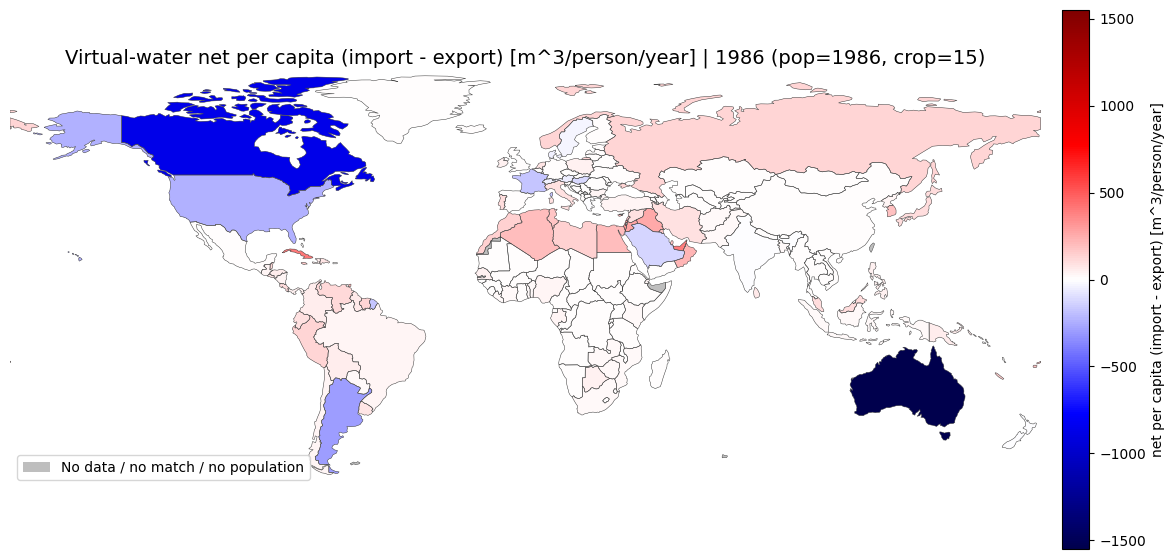

In [6]:
import csv
import pandas as pd
from percapita_utils import animate_vwt_net_import_export_percapita

COUNTRY_POP_CSV   = r"C:\修論研究\VWT_historical_data\country_population.csv"
COUNTRY_LIST_XLSX = r"C:\修論研究\VWT_historical_data\country_list.xlsx"
VWT_NPY_TEMPLATE  = r"C:\修論研究\VWT_historical_data\VWT_npy\VWT_{crop}_{year}.npy"
NE_COUNTRIES_SHP  = r"C:\修論研究\ne_110m_admin_0_countries.zip!ne_110m_admin_0_countries.shp"

rows = []
with open(COUNTRY_POP_CSV, "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        rows.append(row)

country_population = pd.DataFrame(rows)

anim = animate_vwt_net_import_export_percapita(
    crop=15,
    year_start=1986,
    year_end=2016,
    country_list_xlsx=COUNTRY_LIST_XLSX,
    vwt_npy_template=VWT_NPY_TEMPLATE,
    ne_countries_shp=NE_COUNTRIES_SHP,
    population_df=country_population,   # ここがポイント
    pop_iso3_col="Country Code",
    pop_year_col="Year",
    pop_value_col="Value",
    fps=6,
    out_gif=r"C:\修論研究\VWT_historical_data\net_pc_crop15_1986_2016.gif",
    cmap="seismic",
    clip_quantile=0.995,
)


In [7]:
# percapita_utils.py に追加した関数
from pathlib import Path
from typing import Optional
import numpy as np
import pandas as pd

# 既存の補助関数/定数を使う前提:
# _find_column, _clean_iso3, extract_population_by_iso3_for_year
# ISO3_FIX, USSR_ALIASES, USSR_NAME_ALIASES

def save_vwt_net_and_percapita_npy_by_year(
    crop: int,
    year_start: int,
    year_end: int,
    *,
    country_list_xlsx: str,
    vwt_npy_template: str,
    population_df: pd.DataFrame,
    out_dir: str,
    pop_iso3_col: Optional[str] = None,
    pop_year_col: Optional[str] = None,
    pop_value_col: Optional[str] = None,
    population_year: Optional[int] = None,
    net_npy_template: str = "net_{crop}_{year}.npy",
    net_pc_npy_template: str = "net_pc_{crop}_{year}.npy",
    iso3_order_npy: str = "iso3_order.npy",
    save_iso3_each_year: bool = False,
    iso3_yearly_npy_template: str = "iso3_{crop}_{year}.npy",
    ussr_until_year: int = 1991,
) -> pd.DataFrame:
    years = list(range(int(year_start), int(year_end) + 1))
    if len(years) == 0:
        raise ValueError("year_start <= year_end になるように指定してください。")

    cl = pd.read_excel(country_list_xlsx)
    iso3_col = _find_column(cl.columns, exact=["iso3", "iso_a3", "iso-3", "iso_3"], contains=["iso3"])
    if iso3_col is None:
        raise ValueError(f"country_list に ISO3 列が見つからない。columns={list(cl.columns)}")

    vwt0 = np.load(vwt_npy_template.format(crop=crop, year=years[0])).astype(float)
    if vwt0.ndim != 2:
        raise ValueError(f"VWTmat must be 2D. got shape={vwt0.shape}")

    n = min(vwt0.shape[0], vwt0.shape[1])
    if len(cl) < n:
        raise ValueError(f"country_list rows ({len(cl)}) < VWT size ({n}). country_listの行数が足りない。")

    cl_n = cl.iloc[:n].copy()
    cl_n["_iso3_raw"] = cl_n[iso3_col].astype(str)
    cl_n["_iso3"] = _clean_iso3(cl_n["_iso3_raw"]).replace(ISO3_FIX)

    country_name_col = _find_column(cl_n.columns, exact=["country name", "country", "name"], contains=["country"])
    if country_name_col is None:
        country_name_col = cl_n.columns[0]
    cl_n["_country_upper"] = cl_n[country_name_col].astype(str).str.strip().str.upper()
    missing_iso = cl_n["_iso3"].isna()
    cl_n.loc[missing_iso & cl_n["_country_upper"].isin(USSR_NAME_ALIASES), "_iso3"] = "USSR"

    iso3_order = (
        cl_n["_iso3"]
        .replace({k: "RUS" for k in USSR_ALIASES})
        .dropna()
        .astype(str)
        .sort_values()
        .drop_duplicates()
        .to_numpy()
    )
    if iso3_order.size == 0:
        raise ValueError("iso3_order が空です。country_list のISO3を確認してください。")

    out_path = Path(out_dir)
    out_path.mkdir(parents=True, exist_ok=True)
    np.save(out_path / iso3_order_npy, iso3_order)

    pop_cache: dict[int, pd.DataFrame] = {}
    summary_rows = []

    for y in years:
        vwt_y = np.load(vwt_npy_template.format(crop=crop, year=y)).astype(float)
        vwt_y = vwt_y[:n, :n]

        import_by_country = np.nansum(vwt_y, axis=0)
        export_by_country = np.nansum(vwt_y, axis=1)
        df_y = pd.DataFrame(
            {
                "iso3_raw": cl_n["_iso3"].values,
                "import": import_by_country,
                "export": export_by_country,
            }
        )

        if int(y) <= int(ussr_until_year):
            df_y["iso3"] = df_y["iso3_raw"].replace({k: "RUS" for k in USSR_ALIASES})
        else:
            df_y["iso3"] = df_y["iso3_raw"]

        df_y = df_y[df_y["iso3"].notna()].copy()
        df_y = df_y.groupby("iso3", as_index=False)[["import", "export"]].sum()
        df_y["net"] = df_y["import"] - df_y["export"]

        pop_y = int(population_year) if population_year is not None else int(y)
        if pop_y not in pop_cache:
            pop_cache[pop_y] = extract_population_by_iso3_for_year(
                population_df=population_df,
                year=pop_y,
                iso3_col=pop_iso3_col,
                year_col=pop_year_col,
                pop_col=pop_value_col,
                ussr_until_year=ussr_until_year,
            )
        df_y = df_y.merge(pop_cache[pop_y], on="iso3", how="left")

        valid_pop = np.isfinite(df_y["population"]) & (df_y["population"] > 0)
        df_y["net_pc"] = np.where(valid_pop, df_y["net"] / df_y["population"], np.nan)

        aligned = df_y.set_index("iso3").reindex(iso3_order)
        net_arr = aligned["net"].to_numpy(dtype=float)
        net_pc_arr = aligned["net_pc"].to_numpy(dtype=float)

        net_name = net_npy_template.format(crop=crop, year=y)
        net_pc_name = net_pc_npy_template.format(crop=crop, year=y)
        np.save(out_path / net_name, net_arr)
        np.save(out_path / net_pc_name, net_pc_arr)

        if save_iso3_each_year:
            iso_name = iso3_yearly_npy_template.format(crop=crop, year=y)
            np.save(out_path / iso_name, iso3_order)

        summary_rows.append(
            {
                "year": int(y),
                "pop_year": int(pop_y),
                "n_iso3": int(iso3_order.size),
                "n_valid_population": int(np.isfinite(net_pc_arr).sum()),
                "net_npy": str(out_path / net_name),
                "net_pc_npy": str(out_path / net_pc_name),
            }
        )

    summary = pd.DataFrame(summary_rows)
    print(f"Saved yearly npy: years={years[0]}-{years[-1]}, files={len(years) * 2}")
    print(f"Saved iso3 order: {out_path / iso3_order_npy} (n={iso3_order.size})")
    return summary


In [9]:
import importlib
import percapita_utils

print(percapita_utils.__file__)  # 読み込まれている実体を確認
percapita_utils = importlib.reload(percapita_utils)

print(hasattr(percapita_utils, "save_vwt_net_and_percapita_npy_by_year"))


c:\修論研究\codes\percapita_utils.py
True


In [10]:
summary = percapita_utils.save_vwt_net_and_percapita_npy_by_year(
    crop=15,
    year_start=1986,
    year_end=2016,
    country_list_xlsx=COUNTRY_LIST_XLSX,
    vwt_npy_template=VWT_NPY_TEMPLATE,
    population_df=country_population,
    out_dir=r"C:\修論研究\VWT_historical_data\net_npy",
    pop_iso3_col="Country Code",
    pop_year_col="Year",
    pop_value_col="Value",
)
summary.head()


Saved yearly npy: years=1986-2016, files=62
Saved iso3 order: C:\修論研究\VWT_historical_data\net_npy\iso3_order.npy (n=230)


,year,pop_year,n_iso3,n_valid_population,net_npy,net_pc_npy
0,1986,1986,230,210,C:\修論研究\VWT_historical_data\net_npy\net_15_198...,C:\修論研究\VWT_historical_data\net_npy\net_pc_15_...
1,1987,1987,230,210,C:\修論研究\VWT_historical_data\net_npy\net_15_198...,C:\修論研究\VWT_historical_data\net_npy\net_pc_15_...
2,1988,1988,230,210,C:\修論研究\VWT_historical_data\net_npy\net_15_198...,C:\修論研究\VWT_historical_data\net_npy\net_pc_15_...
3,1989,1989,230,210,C:\修論研究\VWT_historical_data\net_npy\net_15_198...,C:\修論研究\VWT_historical_data\net_npy\net_pc_15_...
4,1990,1990,230,210,C:\修論研究\VWT_historical_data\net_npy\net_15_199...,C:\修論研究\VWT_historical_data\net_npy\net_pc_15_...
